In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
transform = transforms.ToTensor()
train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_raw = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
train_images = train_raw.data.float() / 255.0        # shape: (60000, 28, 28)
train_images = train_images.unsqueeze(1)              # shape: (60000, 1, 28, 28)
train_labels = train_raw.targets                      # shape: (60000,)
test_images = test_raw.data.float() / 255.0
test_images = test_images.unsqueeze(1)
test_labels = test_raw.targets

In [5]:
train_dataset = TensorDataset(train_images, train_labels)
test_dataset = TensorDataset(test_images, test_labels)

In [8]:
test_dataset

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
print(train_loader)

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(3*3*128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [11]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 10)   # 10 classes, not 1
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])   # take last timestep's hidden state
        return out

In [12]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=5, is_rnn=False):
    train_losses = []
    train_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            if is_rnn:
                images = images.squeeze(1)   # (batch, 1, 28, 28) -> (batch, 28, 28)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")
    
    return train_losses, train_accuracies

In [13]:
cnn_model = CNN()
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_losses, cnn_accs = train_model(cnn_model, train_loader, criterion, cnn_optimizer, num_epochs=5, is_rnn=False)

Epoch [1/5] - Loss: 0.1779 - Accuracy: 0.9442
Epoch [2/5] - Loss: 0.0449 - Accuracy: 0.9861
Epoch [3/5] - Loss: 0.0309 - Accuracy: 0.9902
Epoch [4/5] - Loss: 0.0254 - Accuracy: 0.9913
Epoch [5/5] - Loss: 0.0187 - Accuracy: 0.9940


In [14]:
rnn_model = RNN(input_size=28)
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_losses, rnn_accs = train_model(rnn_model, train_loader, criterion, rnn_optimizer, num_epochs=5, is_rnn=True)

Epoch [1/5] - Loss: 0.9212 - Accuracy: 0.6881
Epoch [2/5] - Loss: 0.4816 - Accuracy: 0.8498
Epoch [3/5] - Loss: 0.2968 - Accuracy: 0.9120
Epoch [4/5] - Loss: 0.2255 - Accuracy: 0.9335
Epoch [5/5] - Loss: 0.1895 - Accuracy: 0.9444


In [15]:
def evaluate_model(model, test_loader, is_rnn=False):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            if is_rnn:
                images = images.squeeze(1)   # (batch, 1, 28, 28) -> (batch, 28, 28)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return all_preds, all_labels, accuracy

In [16]:
cnn_preds, cnn_labels, cnn_acc = evaluate_model(cnn_model, test_loader, is_rnn=False)
rnn_preds, rnn_labels, rnn_acc = evaluate_model(rnn_model, test_loader, is_rnn=True)

Test Accuracy: 0.9920
Test Accuracy: 0.9309


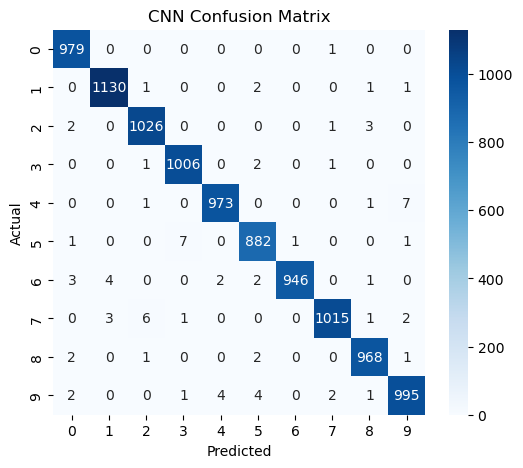

CNN Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
cnn_cm = confusion_matrix(cnn_labels, cnn_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("CNN Classification Report:\n", classification_report(cnn_labels, cnn_preds))

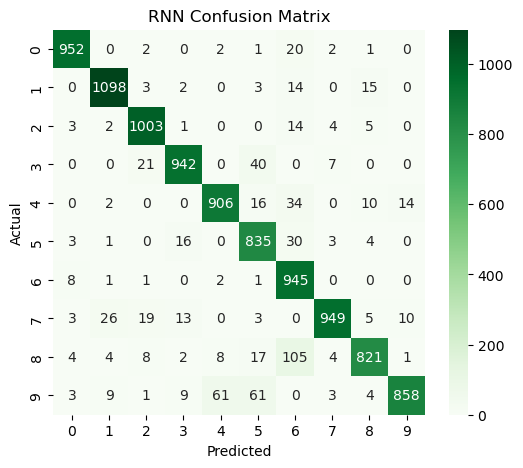

RNN Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       980
           1       0.96      0.97      0.96      1135
           2       0.95      0.97      0.96      1032
           3       0.96      0.93      0.94      1010
           4       0.93      0.92      0.92       982
           5       0.85      0.94      0.89       892
           6       0.81      0.99      0.89       958
           7       0.98      0.92      0.95      1028
           8       0.95      0.84      0.89       974
           9       0.97      0.85      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [19]:
rnn_cm = confusion_matrix(rnn_labels, rnn_preds)
plt.figure(figsize=(6,5))
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Greens')
plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("RNN Classification Report:\n", classification_report(rnn_labels, rnn_preds))

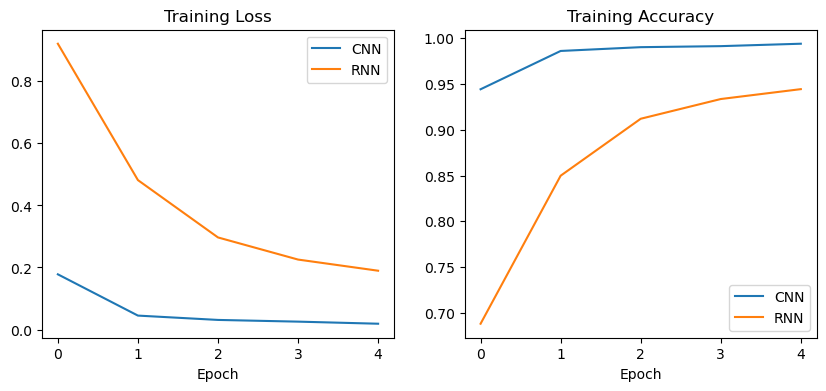

In [21]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(cnn_losses, label='CNN')
plt.plot(rnn_losses, label='RNN')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(cnn_accs, label='CNN')
plt.plot(rnn_accs, label='RNN')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.show()

### CNN performs better than RNN